<div style="background-color: #f3e8ff; border: 1px solid #d8b4fe; color: #6b21a8; padding: 15px; border-radius: 4px;">
<b> Oxygen data processing </b> <br> 
First code is the complete one, whilst the second is just for the overlay
</div>

In [1]:
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pathlib import Path
import sys

<div style="background-color: #f3e8ff; border: 1px solid #d8b4fe; color: #6b21a8; padding: 15px; border-radius: 4px;">
<b> Full code </b> <br> 
Separate plots, rate calculations and overlay
</div>

In [2]:
# Okabe-Ito colourblind-safe palette
COLORS = {"uphill": "#0072B2", "downhill": "#D55E00", "raw": "#999999", "smooth": "#E69F00", "rate": "#CC79A7"}
OVERLAY_COLORS = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#0072B2", "#D55E00", "#F0E442"]

def process_and_plot(file_path, window_seconds=31, polyorder=3, min_duration=45, fit_window_sec=30):
    print(f"\n{'='*60}\nProcessing: {file_path}\n{'='*60}")
    
    # 1. Dynamic Load
    with open(file_path, "r", errors="ignore") as f:
        header = next((i for i, line in enumerate(f) if line.strip().lower().startswith("time,oxygen 1")), None)
    if header is None:
        raise ValueError(f"No 'Time,Oxygen 1' header found in {file_path}")
        
    df = pd.read_csv(file_path, skiprows=header, index_col=False)
    df.columns = df.columns.str.strip()
    df = df.dropna(subset=["Time", "Oxygen 1"]).astype({"Time": float, "Oxygen 1": float})
    df = df.sort_values("Time").reset_index(drop=True)
    t, o2 = df["Time"].values, df["Oxygen 1"].values
    
    # 2. Smooth & Continuous Rate Calculation
    dt = np.median(np.diff(t))
    window = max(int(round(window_seconds / dt)) | 1, polyorder + 2) 
    o2_smooth = savgol_filter(o2, window, polyorder)
    rate = savgol_filter(o2, window, polyorder, deriv=1, delta=dt) * 60
    
    # 3. Detect Rough Phases & Isolate Centred 30s Window
    threshold = 4 * (o2 - o2_smooth).std()
    phase = np.where(rate > threshold, "uphill", np.where(rate < -threshold, "downhill", "flat"))
    boundaries = np.concatenate([[0], np.where(phase[1:] != phase[:-1])[0] + 1, [len(t)]])
    
    rough_segments = []
    for i in range(len(boundaries) - 1):
        s_idx, e_idx = boundaries[i], boundaries[i+1] - 1
        if (t[e_idx] - t[s_idx]) >= min_duration and phase[s_idx] in ["uphill", "downhill"]:
            rough_segments.append((s_idx, e_idx, phase[s_idx]))

    segments = []
    rates = []
    half_win = int(round((fit_window_sec / 2) / dt))
    
    for s_idx, e_idx, direction in rough_segments:
        # Calculate the geometric midpoint of the phase to avoid plateau lag
        mid_idx = s_idx + (e_idx - s_idx) // 2
        
        # Isolate exactly 30 seconds around the midpoint
        w_s = max(0, mid_idx - half_win)
        w_e = min(len(t) - 1, mid_idx + half_win)
        segments.append((w_s, w_e, direction))
        
        # Linear regression strictly on the 30s window
        slope, _ = np.polyfit(t[w_s:w_e+1], o2[w_s:w_e+1], 1)
        rates.append({"dir": direction, "rate": slope * 60, "start": t[w_s]/60, "end": t[w_e]/60})
        
    # 4. Print and Save Individual Rates
    r_df = pd.DataFrame(rates)
    if not r_df.empty:
        print("Rates per Segment (30s window):")
        for i, row in r_df.iterrows():
            print(f"  Segment {i+1} ({row['dir']}) [{row['start']:.1f}-{row['end']:.1f} min]: {row['rate']:.4f} \u0394O2/min")
        
        # Save table to CSV
        export_df = r_df.copy()
        export_df.index = np.arange(1, len(export_df) + 1)
        export_df.index.name = "Segment"
        export_df = export_df.rename(columns={
            "dir": "Direction", 
            "rate": "Rate_dO2_per_min", 
            "start": "Start_min", 
            "end": "End_min"
        })
        csv_name = f"{Path(file_path).stem}_rates.csv"
        export_df.to_csv(csv_name)
        print(f"Saved {csv_name}")
    
    # 5. Plotting (3 Panels: Kinetic -> Rate -> Segmented)
    fig, (ax_o2, ax_rate, ax_seg) = plt.subplots(3, 1, figsize=(11, 12), sharex=True)
    t_min = t / 60
    
    # Panel 1: Kinetic Trace
    ax_o2.plot(t_min, o2, color=COLORS["raw"], lw=0.6, alpha=0.7, label="Raw")
    ax_o2.plot(t_min, o2_smooth, color=COLORS["smooth"], lw=1.6, label="Smoothed")
    ax_o2.set_ylabel("Oxygen concentration (nmol)")
    ax_o2.set_title("Kinetic O2 Trace")
    ax_o2.legend(loc="best")
    ax_o2.grid(alpha=0.3)
    
    # Panel 2: Continuous Rate
    ax_rate.plot(t_min, rate, color=COLORS["rate"], lw=1.2, label="Calculated Rate")
    ax_rate.axhline(0, color="black", lw=0.5, ls = "--")
    ax_rate.set_ylabel("Rate (nmol / ml / min)")
    ax_rate.set_title("Instantaneous Rate")
    ax_rate.grid(alpha=0.3)
    
    # Panel 3: Segmented Trace (30s windows only)
    ax_seg.plot(t_min, o2, color=COLORS["raw"], lw=0.6, alpha=0.7)
    for s_idx, e_idx, direction in segments:
        ax_seg.plot(t_min[s_idx:e_idx+1], o2_smooth[s_idx:e_idx+1], color=COLORS[direction], lw=3.0)
        
    handles = [Line2D([0], [0], color=COLORS[d], lw=3.0, label=d) for d in ["uphill", "downhill"]]
    if handles:
        ax_seg.legend(handles=handles, loc="best")
    ax_seg.set_xlabel("Time (min)")
    ax_seg.set_ylabel("Oxygen concentration (nmol)")
    ax_seg.set_title("Photosynthesis and Respiration rates")
    ax_seg.grid(alpha=0.3)
    
    plt.tight_layout()
    out_name = f"{Path(file_path).stem}_analysis.svg"
    #plt.savefig(out_name, format="svg")
    print(f"Saved {out_name}")
    plt.show() 
    
    return t, o2, o2_smooth, rate, Path(file_path).stem

def plot_overlay(datasets, output_name="combined_o2_kinetics_overlay"):
    print(f"\n{'='*60}\nBuilding Combined Overlay Plot\n{'='*60}")
    fig, (ax_o2, ax_rate) = plt.subplots(2, 1, figsize=(11, 8), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

    for i, (t, o2, o2_smooth, rate, label) in enumerate(datasets):
        t_min = t / 60
        colour = OVERLAY_COLORS[i % len(OVERLAY_COLORS)]

        # Top: O2 Overlay (No Segments)
        ax_o2.plot(t_min, o2, color="#999999", lw=0.4, alpha=0.4)
        ax_o2.plot(t_min, o2_smooth, color=colour, lw=1.6, label=label)

        # Bottom: Rate Overlay
        ax_rate.plot(t_min, rate, color=colour, lw=1.2, label=label)

    ax_o2.set_ylabel("Oxygen Concentration (nmol)")
    ax_o2.set_title("O2 Kinetic Trace Overlay")
    ax_o2.legend(loc="best", fontsize=9)
    ax_o2.grid(alpha=0.3)

    ax_rate.axhline(0, color="black", lw=0.8)
    ax_rate.set_xlabel("Time (min)")
    ax_rate.set_ylabel("Rate (nmol/min)")
    ax_rate.set_title("Instantaneous Rate Overlay")
    ax_rate.legend(loc="best", fontsize=9)
    ax_rate.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_name}.svg", format="svg")
    print(f"Saved overlay plot: {output_name}.svg")
    plt.show()


Processing: Dummy_CONTROL.csv
Rates per Segment (30s window):
  Segment 1 (uphill) [9.6-10.1 min]: 3.5929 ΔO2/min
  Segment 2 (uphill) [13.2-13.8 min]: 8.1303 ΔO2/min
  Segment 3 (uphill) [17.0-17.5 min]: 8.0344 ΔO2/min
  Segment 4 (uphill) [20.1-20.6 min]: 10.4160 ΔO2/min
  Segment 5 (uphill) [23.4-23.9 min]: 7.2064 ΔO2/min
Saved Dummy_CONTROL_rates.csv
Saved Dummy_CONTROL_analysis.svg


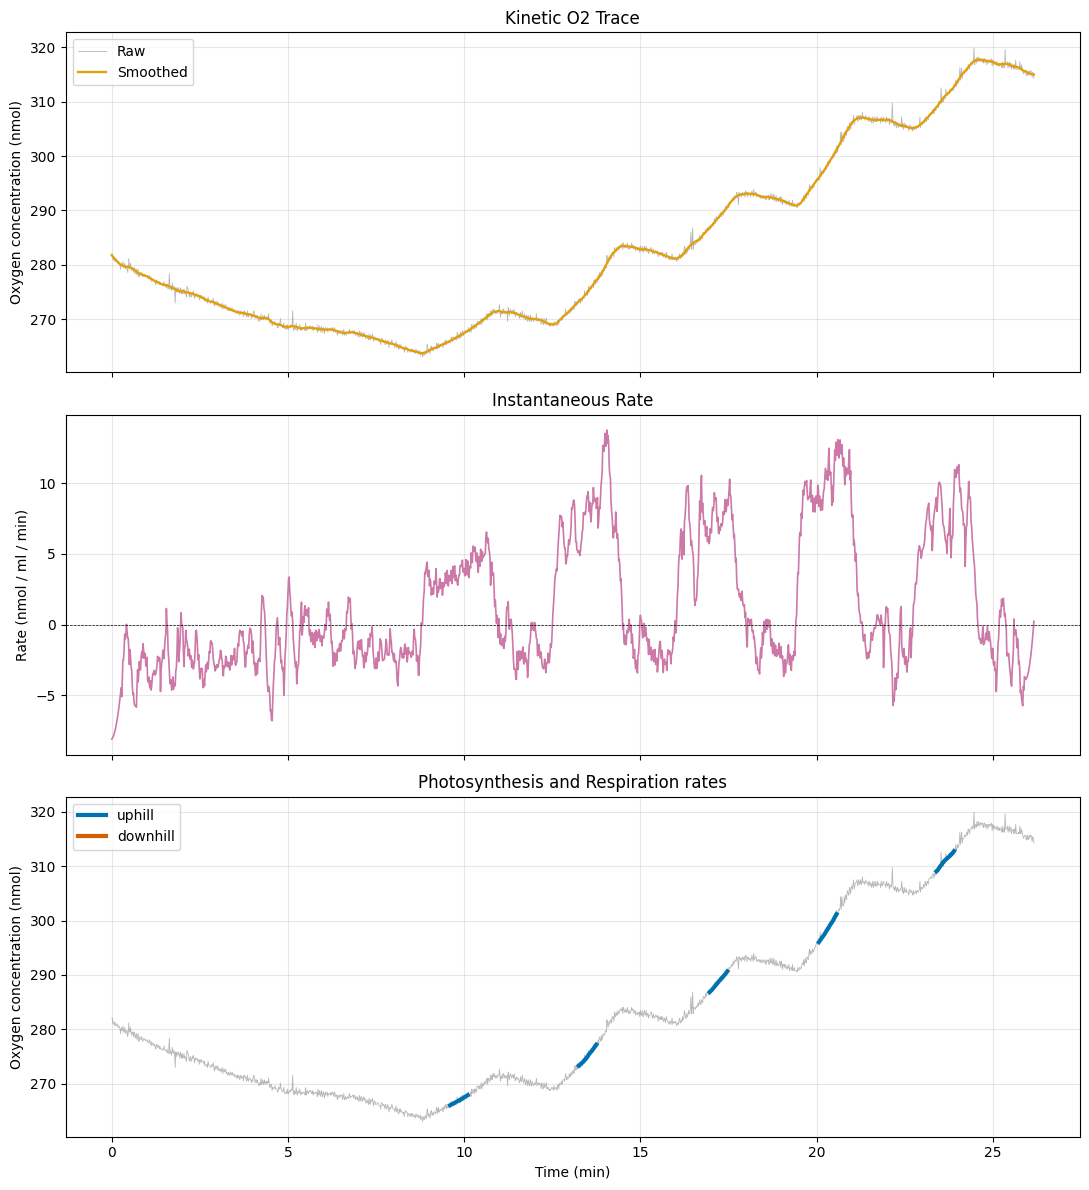


Processing: Dummy_CONDITION.csv
Rates per Segment (30s window):
  Segment 1 (downhill) [0.2-0.7 min]: -4.2499 ΔO2/min
  Segment 2 (uphill) [9.8-10.3 min]: 3.7229 ΔO2/min
  Segment 3 (uphill) [13.3-13.8 min]: 8.4245 ΔO2/min
  Segment 4 (uphill) [16.6-17.1 min]: 6.9874 ΔO2/min
  Segment 5 (uphill) [20.0-20.5 min]: 10.3271 ΔO2/min
  Segment 6 (uphill) [23.3-23.8 min]: 7.3911 ΔO2/min
Saved Dummy_CONDITION_rates.csv
Saved Dummy_CONDITION_analysis.svg


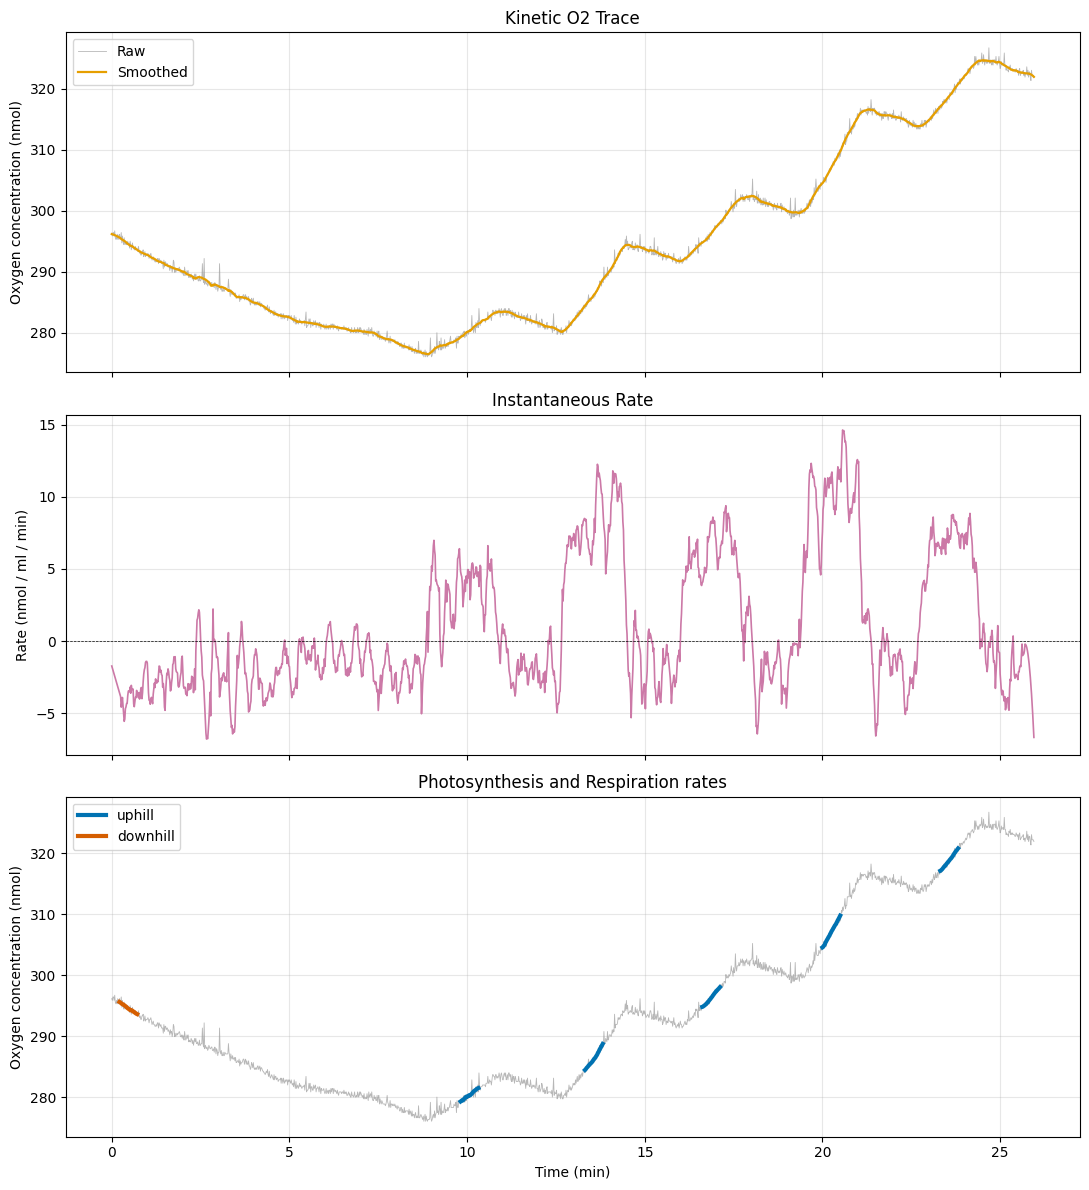


Building Combined Overlay Plot
Saved overlay plot: combined_o2_kinetics_overlay.svg


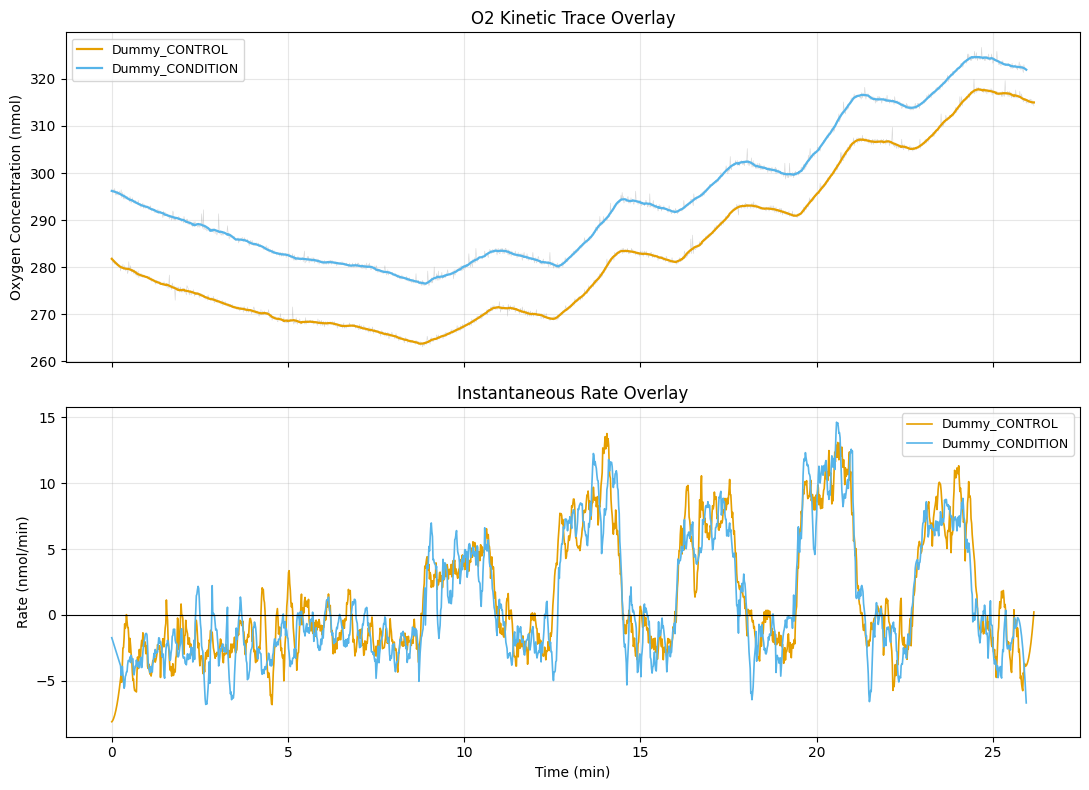

In [3]:
if __name__ == "__main__":
    # Add files to this list
    input_files = [
        "Dummy_CONTROL.csv",
        "Dummy_CONDITION.csv"
    ]
    
    datasets = []
    
    # 1. Process individual files
    for f in input_files:
        try:
            # Append extracted arrays for overlay step
            datasets.append(process_and_plot(f))
        except Exception as e:
            print(f"Error processing {f}: {e}")
            
    # 2. Generate overlay if data was successfully processed
    if datasets:
        plot_overlay(datasets)

<div style="background-color: #f3e8ff; border: 1px solid #d8b4fe; color: #6b21a8; padding: 15px; border-radius: 4px;">
<b> Overlay code </b> <br> 
Only the overlay chunk
</div>

In [4]:
def find_header_row(file_path, max_scan=60):
    with open(file_path, "r", errors="ignore") as f:
        for i, line in enumerate(f):
            if i > max_scan:
                break
            # Explicitly match "oxygen 1" to skip the uppercase general header
            if line.strip().lower().startswith("time,oxygen 1"):
                return i
    raise ValueError(f"Could not find a 'Time,Oxygen 1' header row in {file_path}.")


def load_o2_trace(file_path):
    header_row = find_header_row(file_path)
    df = pd.read_csv(file_path, skiprows=header_row, index_col=False)
    df.columns = df.columns.str.strip()

    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")
    df["Oxygen 1"] = pd.to_numeric(df["Oxygen 1"], errors="coerce")
    df = df.dropna(subset=["Time", "Oxygen 1"]).sort_values("Time").reset_index(drop=True)

    return df["Time"].values, df["Oxygen 1"].values


def compute_rate(t, o2, window_seconds=31, polyorder=3):
    dt = np.median(np.diff(t))  
    window = int(round(window_seconds / dt))
    if window % 2 == 0:
        window += 1
    window = max(window, polyorder + 2)

    o2_smooth = savgol_filter(o2, window_length=window, polyorder=polyorder)
    rate_per_sec = savgol_filter(o2, window_length=window, polyorder=polyorder,
                                  deriv=1, delta=dt)
    rate_per_min = rate_per_sec * 60

    return o2_smooth, rate_per_min


def plot_kinetic_and_rate(datasets, output_name):
    fig, (ax_o2, ax_rate) = plt.subplots(
        nrows=2, ncols=1, figsize=(11, 8), sharex=True,
        gridspec_kw={"height_ratios": [1, 1]}
    )

    # Color palettes for multiple files
    colors_o2 = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#0072B2", "#D55E00", "#F0E442"]
    colors_rate = ["#E69F00", "#56B4E9", "#009E73", "#CC79A7", "#0072B2", "#D55E00", "#F0E442"]

    for i, (t, o2, o2_smooth, rate_per_min, label) in enumerate(datasets):
        t_min = t / 60
        c_o2 = colors_o2[i % len(colors_o2)]
        c_rate = colors_rate[i % len(colors_rate)]

        # Top plot: O2 trace
        ax_o2.plot(t_min, o2, color="#999999", linewidth=0.4, alpha=0.4) 
        ax_o2.plot(t_min, o2_smooth, color=c_o2, linewidth=1.6, label=label)
        
        # Bottom plot: Rate
        ax_rate.plot(t_min, rate_per_min, color=c_rate, linewidth=1.2, label=label)

    ax_o2.set_ylabel("Oxygen Concentration (nmol)") 
    ax_o2.set_title("O2 kinetic trace")
    ax_o2.legend(loc="best", fontsize=9)
    ax_o2.grid(alpha=0.3)

    ax_rate.axhline(0, color="black", linewidth=0.8)
    ax_rate.set_xlabel("Time (min)")
    ax_rate.set_ylabel("Rate (nmol / ml / min)")
    ax_rate.set_title("Instantaneous rate")
    ax_rate.legend(loc="best", fontsize=9)
    ax_rate.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{output_name}.svg", format="svg")
    print(f"Saved {output_name}.svg")

Saved O2_kinetic_comparison.svg


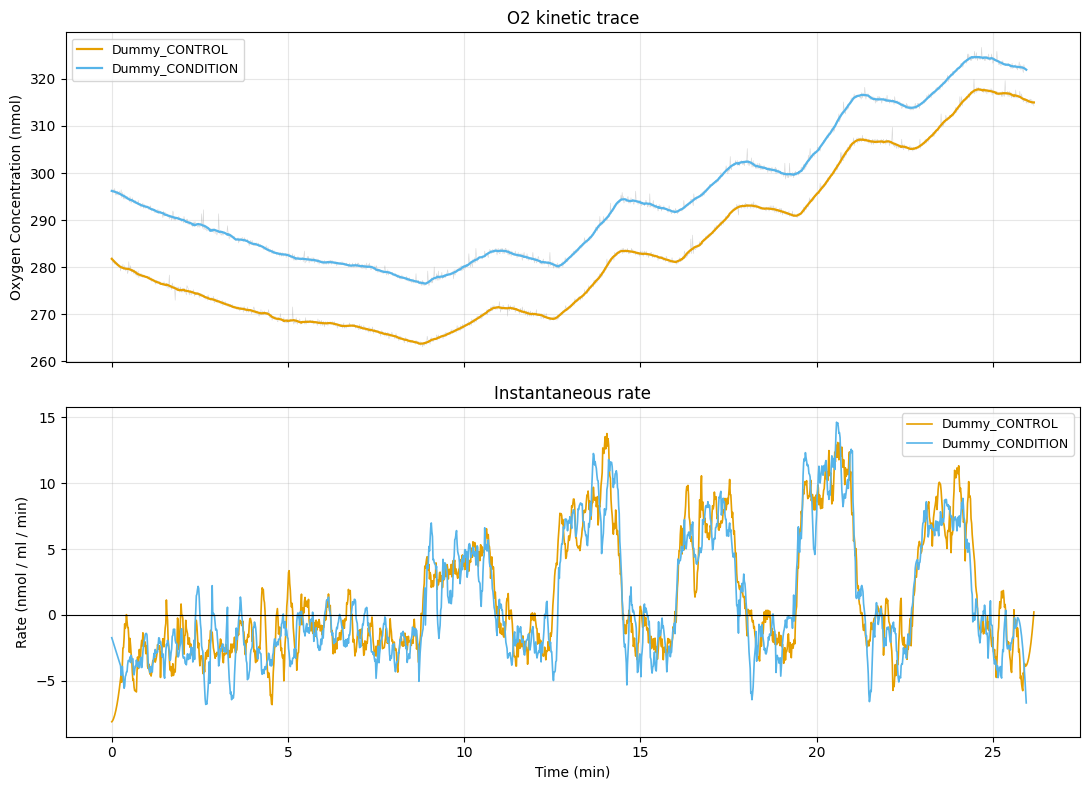

In [7]:
if __name__ == "__main__":
    # 1. List your files directly here
    input_files = [
        "Dummy_CONTROL.csv",
        "Dummy_CONDITION.csv"
    ]
    
    
    output_name = "O2_kinetic_comparison"
    datasets = []

    # 2. Loop through the list to load and compute rates
    for file_path in input_files:
        t, o2 = load_o2_trace(file_path)
        o2_smooth, rate_per_min = compute_rate(t, o2)
        
        # Strip '.csv' from the filename for a cleaner legend label
        label = file_path.replace(".csv", "")
        datasets.append((t, o2, o2_smooth, rate_per_min, label))

    # 3. Plot the combined dataset list
    plot_kinetic_and_rate(datasets, output_name)